# 04 · Why batteries are hard for aviation

Ground vehicles tolerate heavy batteries; aircraft do not. An aircraft must **lift its energy storage for the whole flight**, and a heavier battery needs more lift, more wing, more power — which needs more battery. This notebook makes that vicious circle visible by sweeping the one number that matters most: **battery specific energy** [Wh/kg].

## Cell-level vs system-level specific energy

Be careful what 'Wh/kg' means:

- A modern Li-ion **cell** reaches ~250–300 Wh/kg today; lab chemistries promise more.
- The **pack** is heavier than its cells: add casing, busbars, the **battery management system**, and a **thermal-management system** (cooling). Pack-level specific energy is typically **20–40% lower** than cell-level.
- You also cannot use the full charge: a **usable state-of-charge window** (e.g. 80%) and reserve further cut the *effective* Wh/kg the aircraft sees.

So the number PhlyGreen divides the required energy by is an **aircraft-level effective specific energy**, always well below the headline cell figure.

In [1]:
# --- environment setup (educational tutorials) ---------------------------------
# These notebooks teach concepts *through* PhlyGreen. They use the real design API where
# it exists and small, clearly-labelled pedagogical proxies where it does not.
import warnings
warnings.filterwarnings("ignore")     # keep the solver's internal chatter out of the output
import numpy as np
import matplotlib.pyplot as plt

from _learning_utils import add_examples_to_path
add_examples_to_path()                # puts trunk/examples on sys.path (no absolute paths)

import PhlyGreen as pg
from PhlyGreen import postprocess as pp

from common import hybrid_config
from _learning_utils import safe_design, set_battery_specific_energy

# The baseline hybrid draws up to 50% of cruise power from the battery (phi).
SE_grid = [200, 400, 600, 800, 1000, 1500]      # battery specific energy [Wh/kg]
print('sweeping battery specific energy [Wh/kg]:', SE_grid)

sweeping battery specific energy [Wh/kg]: [200, 400, 600, 800, 1000, 1500]


## Sweep specific energy and catch the infeasible cases

For each specific energy we resize the whole aircraft. At low Wh/kg the battery is so heavy the weight loop **cannot converge** — that is not a bug, it is the physics telling you the design is infeasible. `safe_design` flags those instead of crashing.

In [2]:
res_wto, res_frac, feas = [], [], []
for se in SE_grid:
    cfg = hybrid_config('I')
    set_battery_specific_energy(cfg, se)
    res, ok, note = safe_design(cfg)
    feas.append(ok)
    res_wto.append(res.WTO if ok else np.nan)
    res_frac.append((res.WBat / res.WTO) if ok else np.nan)
    tag = f"WTO {res.WTO:,.0f} kg, battery {res.WBat:,.0f} kg ({100*res.WBat/res.WTO:.1f}%)" if ok else f'INFEASIBLE ({note.split(":")[0]})'
    print(f'{se:5d} Wh/kg : {tag}')
res_wto, res_frac = np.array(res_wto), np.array(res_frac)

  200 Wh/kg : INFEASIBLE (ValueError)


  400 Wh/kg : INFEASIBLE (ValueError)


  600 Wh/kg : WTO 38,336 kg, battery 7,536 kg (19.7%)


  800 Wh/kg : WTO 29,473 kg, battery 4,345 kg (14.7%)


 1000 Wh/kg : WTO 25,790 kg, battery 3,042 kg (11.8%)


 1500 Wh/kg : WTO 22,047 kg, battery 1,733 kg (7.9%)


## Plot the battery wall

Battery **mass fraction** and **MTOW** versus specific energy. The greyed band marks the infeasible region where no design closes.

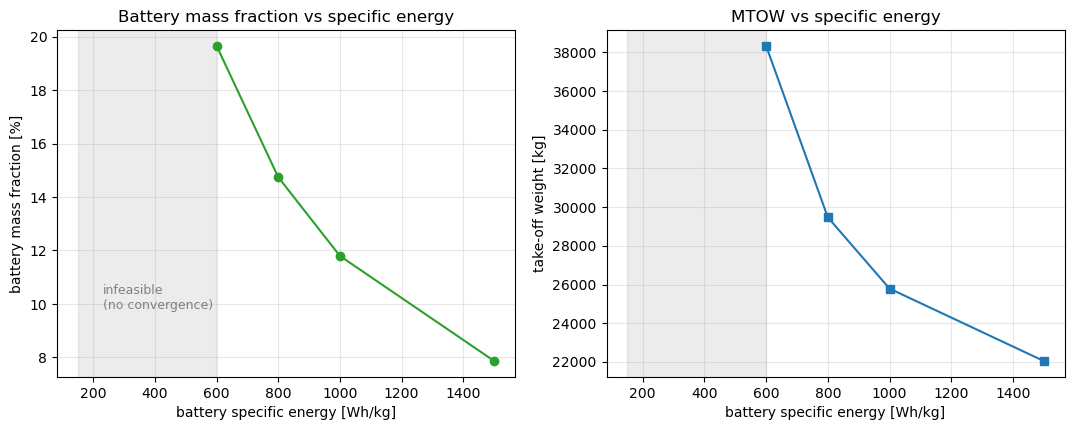

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
se = np.array(SE_grid, dtype=float)
first_feasible = se[np.argmax(np.array(feas))] if any(feas) else se[-1]
for ax in (axL, axR):
    ax.axvspan(se.min()-50, first_feasible-1, color='gray', alpha=0.15)
    ax.text(se.min()+20, ax.get_ylim()[1] if False else 0, '', )
axL.plot(se, res_frac*100, 'o-', color='tab:green')
axL.set_xlabel('battery specific energy [Wh/kg]'); axL.set_ylabel('battery mass fraction [%]')
axL.set_title('Battery mass fraction vs specific energy'); axL.grid(alpha=0.3)
axR.plot(se, res_wto, 's-', color='tab:blue')
axR.set_xlabel('battery specific energy [Wh/kg]'); axR.set_ylabel('take-off weight [kg]')
axR.set_title('MTOW vs specific energy'); axR.grid(alpha=0.3)
axL.annotate('infeasible\n(no convergence)', xy=(se.min()+30, np.nanmax(res_frac*100)*0.5),
             color='gray', fontsize=9)
plt.show()

Two things stand out. First, the relationship is **strongly non-linear**: halving the specific energy far more than doubles the battery mass, because of the snowball through the weight loop. Second, below a threshold there is simply **no feasible aircraft** for this mission — the design wall is real and abrupt.

Recall that even the optimistic 1000–1500 Wh/kg points are **above today's cell capability**, and aircraft-level effective specific energy is lower still.

## Key takeaways

1. Aviation is more sensitive to battery mass than cars because **energy is carried, not rolled** — and through a *coupled* weight loop that amplifies any mass penalty.
2. **Cell ≠ system.** Pack overhead, BMS, cooling and the usable-SOC window all erode the headline Wh/kg before the aircraft ever sees it.
3. Regional all-electric flight needs effective specific energies far beyond today's cells; near-term electrification is therefore **partial** (hybrid) and **short-range**.

## Questions for students

1. Why is aviation more sensitive to battery mass than ground transport? (Hint: lift, and the weight loop.)
2. Why is cell-level specific energy *not* the same as aircraft-level specific energy? List every step that erodes it.
3. What effective Wh/kg would this regional mission need for a *useful* electric share? Read it off your plot.

## Suggested modifications

- Raise the cruise `phi` (battery power share) in `examples/common.py` and re-sweep — the wall moves to higher Wh/kg.
- Add 250 Wh/kg (a realistic cell) to `SE_grid`. Is the mission feasible at all?
- Shorten the design range and find the specific energy at which 200 Wh/kg becomes feasible.
- Switch to `hybrid_config('II')` (cell-level thermal model) and compare.

---
*These tutorials are educational. Where the full PhlyGreen capability is not exposed (formal constraint feasibility, non-CO₂ climate weighting) the notebook uses a simplified, clearly-labelled proxy — read the comments before trusting any number.*